The boundary value problem  $$u'' = \sin(2\pi x), \quad u'(0)=0, \quad u'(1)=0.$$

The left-hand side:
$$\int_0^1 u''(x)\,dx = u'(1)-u'(0) = \int_0^1 \sin(2\pi x)\,dx.$$\
The right-hand side:
$$\int_0^1 \sin(2\pi x)\,dx = \Big[-\frac{1}{2\pi}\cos(2\pi x)\Big]_0^1 = -\frac{1}{2\pi}(\cos 2\pi-\cos 0)=0.$$

Hence, we have $u'(1)-u'(0)=0-0=0.$\
In fact , we compute $$u'(x)=-\frac{1}{2\pi}\cos(2\pi x)+C_1$$ and using $C_1=1/(2\pi)$ and $u'(0)=0.$ \
Then $$u(x)=\frac{x}{2\pi}-\frac{1}{4\pi^2}\sin(2\pi x)+C $$

**2-order finite difference method** \
$$\frac{u_{i-1}-2u_i+u_{i+1}}{h^2} = \sin(2\pi x_i), x_i=i h,\ i=0,\dots,n,\ h=1/n $$

By using central finite difference approximation for derivative:$$u'(0)\approx\frac{u_1-u_{-1}}{2h}=0\quad\Rightarrow\quad u_{-1}=u_1$$
For $i=0$ $$\frac{u_{-1}-2u_0+u_1}{h^2}=\frac{2u_1-2u_0}{h^2}= \sin(2\pi x_0).$$
For $i=n$ and $u_{n+1}=u_{n-1}$ $$\frac{u_{n-1}-2u_n+u_{n+1}}{h^2}=\frac{2u_{n-1}-2u_n}{h^2}= \sin(2\pi x_n).$$

N	Error		Rate
10	5.27e-03	-
50	2.09e-04	4.65
100	5.24e-05	2.00
150	2.33e-05	1.17
200	1.31e-05	0.83
400	3.27e-06	2.00
800	8.18e-07	2.00


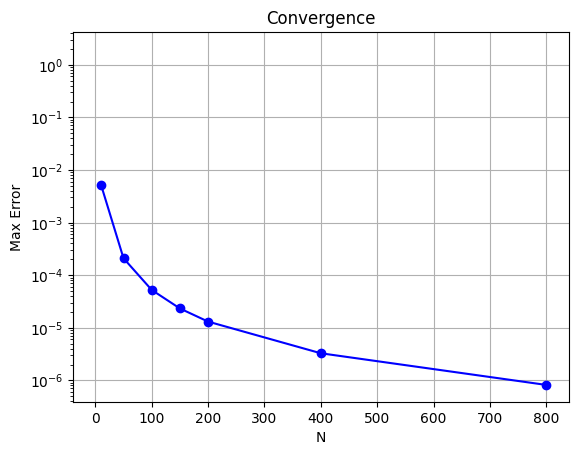

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def exact_solution(x):
    return x/(2*np.pi) - np.sin(2*np.pi*x)/(4*np.pi**2)

def solve_simple(N):
    """Simple FD solver with solution"""
    h = 1.0 / N
    x = np.linspace(0, 1, N+1)

    # Build matrix A
    A = np.zeros((N+1, N+1))
    for i in range(1, N):
        A[i, i-1] = 1
        A[i, i] = -2
        A[i, i+1] = 1

    #  At x=0: u0 = u1
    A[0, 0] = -2
    A[0, 1] = 2

    #  At x=1: uN = u_{N-1}
    A[N, N] = -2
    A[N, N-1] = 2

    # Right-hand side
    F = h**2 * np.sin(2*np.pi*x)

    # Fix one value to remove singularity
    A[0, :] = 0
    A[0, 0] = 1
    F[0] = exact_solution(0)

    # Solve
    u = np.linalg.solve(A, F)
    return x, u

# Check convergence
N_values = [10,50,100,150,200,400,800]
errors = []

print("N\tError\t\tRate")
for i, N in enumerate(N_values):
    x, u_num = solve_simple(N)
    u_exact = exact_solution(x)
    error = np.max(np.abs(u_num - u_exact)) #error value
    errors.append(error)

    if i > 0:
        rate = np.log(errors[i-1]/error) / np.log(2)
        print(f"{N}\t{error:.2e}\t{rate:.2f}")
    else:
        print(f"{N}\t{error:.2e}\t-")

# Plot results
x, u_num = solve_simple(50)
u_exact = exact_solution(x)

plt.plot(1, 2, 2)
plt.semilogy(N_values, errors, 'bo-')
plt.grid(True)
plt.title('Convergence')
plt.xlabel('N'), plt.ylabel('Max Error')
plt.show()